In [7]:
# setup
from mlwpy import *

%matplotlib inline
iris = datasets.load_iris()
tts = skms.train_test_split(iris.data, iris.target,
test_size=.33, random_state=21)
(iris_train_ftrs, iris_test_ftrs,
iris_train_tgt, iris_test_tgt) = tts

In [2]:
# normal usage: build-fit-predict-evaluate
baseline = dummy.DummyClassifier(strategy="most_frequent")
baseline.fit(iris_train_ftrs, iris_train_tgt)
base_preds = baseline.predict(iris_test_ftrs)

base_acc = metrics.accuracy_score(base_preds, iris_test_tgt)
print(base_acc)


0.3


In [3]:
strategies = ['constant', 'uniform', 'stratified', 'prior', 'most_frequent']

# set up args to create different DummyClassifier strategies
baseline_args = [{'strategy': s} for s in strategies]
baseline_args[0]['constant'] = 0  # class 0 is setosa

accuracies = []
for bla in baseline_args:
    baseline = dummy.DummyClassifier(**bla)
    baseline.fit(iris_train_ftrs, iris_train_tgt)
    base_preds = baseline.predict(iris_test_ftrs)
    accuracies.append(metrics.accuracy_score(base_preds, iris_test_tgt))

display(pd.DataFrame({'accuracy': accuracies}, index=strategies))


,accuracy
constant,0.3600
uniform,0.3800
stratified,0.3400
prior,0.3000
most_frequent,0.3000


In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import get_scorer_names
import textwrap

print(textwrap.fill(str(sorted(get_scorer_names())), width=70))


['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score',
'average_precision', 'balanced_accuracy', 'completeness_score',
'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro',
'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score',
'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro',
'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef',
'mutual_info_score', 'neg_brier_score', 'neg_log_loss',
'neg_max_error', 'neg_mean_absolute_error',
'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance',
'neg_mean_poisson_deviance', 'neg_mean_squared_error',
'neg_mean_squared_log_error', 'neg_median_absolute_error',
'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error',
'neg_root_mean_squared_log_error', 'normalized_mutual_info_score',
'positive_likelihood_ratio', 'precision', 'precision_macro',
'precision_micro', 'precision_samples', 'precision_weighted', 'r2',
'rand_score', 'recall', 'recall_macro', 'recall_micro',
'recall_samples'

In [10]:
knn = neighbors.KNeighborsClassifier()
# help(knn.score) # verbose, but complete
print(knn.score.__doc__.splitlines()[0])
print('\n---and---\n')
print("\n".join(knn.score.__doc__.splitlines()[-6:]))



---and---


        Returns
        -------
        score : float
            Mean accuracy of ``self.predict(X)`` w.r.t. `y`.
        


In [11]:
tgt_preds = (
    neighbors.KNeighborsClassifier()
    .fit(iris_train_ftrs, iris_train_tgt)
    .predict(iris_test_ftrs)
)

print("accuracy:", metrics.accuracy_score(iris_test_tgt, tgt_preds))

cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("confusion matrix:", cm, sep="\n")


accuracy: 0.94
confusion matrix:
[[18  0  0]
 [ 0 16  1]
 [ 0  2 13]]


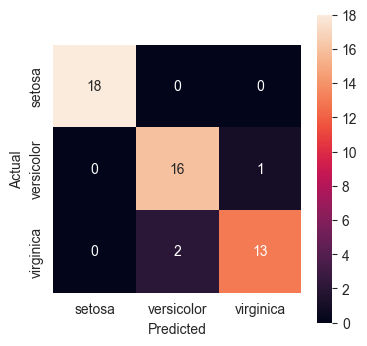

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
ax = sns.heatmap(cm, annot=True, square=True,
xticklabels=iris.target_names,
yticklabels=iris.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual');

In [13]:
macro_prec = metrics.precision_score(iris_test_tgt,
tgt_preds,
average='macro')
print("macro:", macro_prec)
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
n_labels = len(iris.target_names)
print("should equal 'macro avg':",
# correct column # columns
(np.diag(cm) / cm.sum(axis=0)).sum() / n_labels)

macro: 0.9391534391534391
should equal 'macro avg': 0.9391534391534391


In [14]:
print("micro:", metrics.precision_score(iris_test_tgt,
tgt_preds,
average='micro'))
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("should equal avg='micro':",
# TP.sum() / (TP&FP).sum() -->
# all correct / all preds
np.diag(cm).sum() / cm.sum())

micro: 0.94
should equal avg='micro': 0.94


In [15]:
print(metrics.classification_report(iris_test_tgt,
tgt_preds))
# average is a weighted macro average (see text)
# verify sums-across-rows
cm = metrics.confusion_matrix(iris_test_tgt, tgt_preds)
print("row counts equal support:", cm.sum(axis=1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.89      0.94      0.91        17
           2       0.93      0.87      0.90        15

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50

row counts equal support: [18 17 15]


In [17]:
# warning: this is 1 "one" not l "ell"
is_versicolor = iris.target == 1

tts_1c = skms.train_test_split(
    iris.data, is_versicolor, test_size=0.33, random_state=21
)

iris_1c_train_ftrs, iris_1c_test_ftrs, iris_1c_train_tgt, iris_1c_test_tgt = tts_1c

# build, fit, predict (probability scores) for NB model
gnb = naive_bayes.GaussianNB()
prob_true = (
    gnb.fit(iris_1c_train_ftrs, iris_1c_train_tgt)
    .predict_proba(iris_1c_test_ftrs)[:, 1]  # [:, 1] corresponds to "True"
)


FPR : [0.     0.     0.     0.0606 0.0606 0.1212 0.1212 0.1818 1.    ]
TPR : [0.     0.0588 0.8824 0.8824 0.9412 0.9412 1.     1.     1.    ]


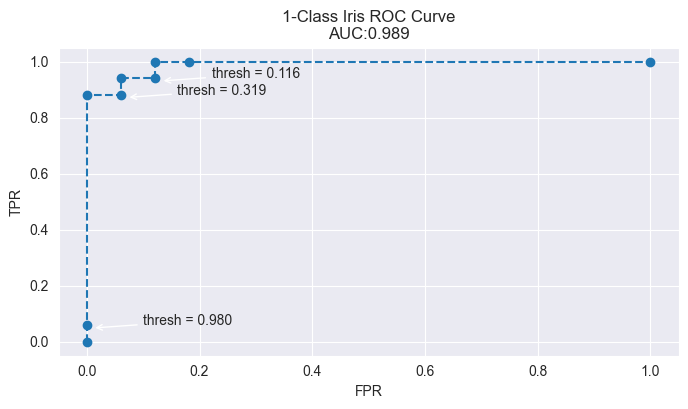

In [18]:
fpr, tpr, thresh = metrics.roc_curve(iris_1c_test_tgt, prob_true)
auc = metrics.auc(fpr, tpr)

print("FPR : {}".format(fpr), "TPR : {}".format(tpr), sep='\n')

# create the main graph
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fpr, tpr, 'o--')
ax.set_title("1-Class Iris ROC Curve\nAUC:{:.3f}".format(auc))
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")

# do a bit of work to label some points with their respective thresholds
investigate = np.array([1, 3, 5])
for idx in investigate:
    th, f, t = thresh[idx], fpr[idx], tpr[idx]
    ax.annotate(
        'thresh = {:.3f}'.format(th),
        xy=(f + 0.01, t - 0.01),
        xytext=(f + 0.1, t),
        arrowprops={'arrowstyle': '->'}
    )


Text(120.72222222222221, 0.5, 'Actual')

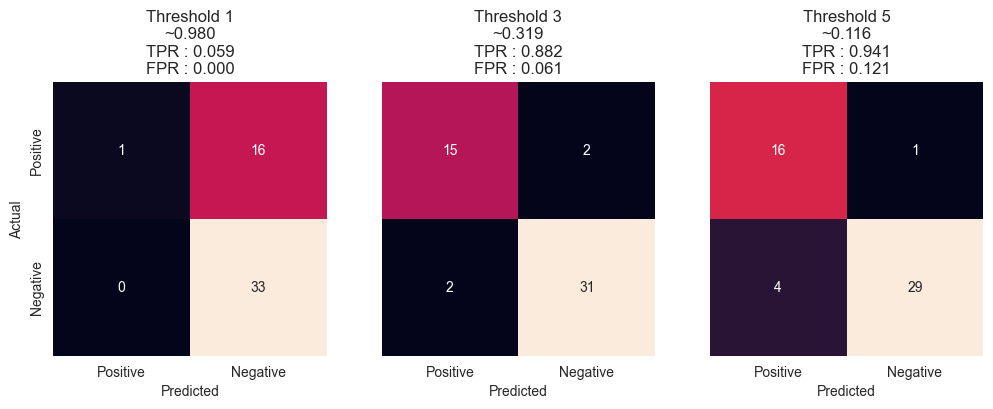

In [19]:
title_fmt = "Threshold {}\n~{:5.3f}\nTPR : {:.3f}\nFPR : {:.3f}"
pn = ['Positive', 'Negative']
add_args = {
    'xticklabels': pn,
    'yticklabels': pn,
    'square': True
}

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(12, 4))

for ax, thresh_idx in zip(axes.flat, investigate):
    preds_at_th = prob_true < thresh[thresh_idx]
    cm = metrics.confusion_matrix(1 - iris_1c_test_tgt, preds_at_th)
    sns.heatmap(cm, annot=True, cbar=False, ax=ax, **add_args)
    ax.set_xlabel('Predicted')
    ax.set_title(
        title_fmt.format(
            thresh_idx,
            thresh[thresh_idx],
            tpr[thresh_idx],
            fpr[thresh_idx]
        )
    )

axes[0].set_ylabel('Actual')


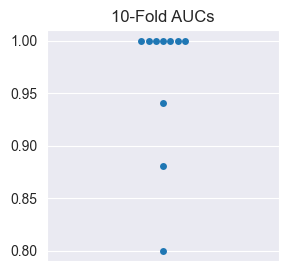

In [20]:
fig,ax = plt.subplots(1, 1, figsize=(3, 3))
model = neighbors.KNeighborsClassifier(3)
cv_auc = skms.cross_val_score(model, iris.data, iris.target==1,
scoring='roc_auc', cv=10)
ax = sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold AUCs');

In [21]:
checkout = [0, 50, 100]
print("Original Encoding")
print(iris.target[checkout])

Original Encoding
[0 1 2]


In [24]:
print("'Multi-label' Encoding")
print(skpre.label_binarize(iris.target, classes=[0, 1, 2])[checkout])


'Multi-label' Encoding
[[1 0 0]
 [0 1 0]
 [0 0 1]]


Text(0, 0.5, 'TPR')

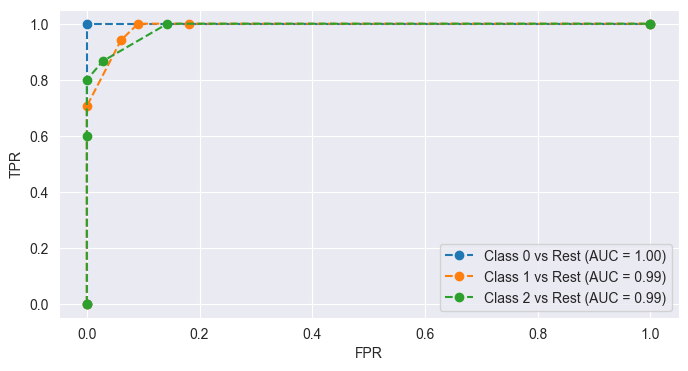

In [26]:
iris_multi_tgt = skpre.label_binarize(iris.target, classes=[0, 1, 2])  # im --> "iris multi"

# Train-test split
im_train_ftrs, im_test_ftrs, im_train_tgt, im_test_tgt = skms.train_test_split(
    iris.data,
    iris_multi_tgt,
    test_size=0.33,
    random_state=21
)

# KNN wrapped in one-vs-rest classifier (3 classifiers)
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
ovr_knn = skmulti.OneVsRestClassifier(knn)

pred_probs = ovr_knn.fit(im_train_ftrs, im_train_tgt).predict_proba(im_test_ftrs)

# Make ROC plots
lbl_fmt = "Class {} vs Rest (AUC = {:.2f})"
fig, ax = plt.subplots(figsize=(8, 4))

for cls in [0, 1, 2]:
    fpr, tpr, _ = metrics.roc_curve(im_test_tgt[:, cls], pred_probs[:, cls])
    label = lbl_fmt.format(cls, metrics.auc(fpr, tpr))
    ax.plot(fpr, tpr, 'o--', label=label)

ax.legend()
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")


In [27]:
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
ovo_knn = skmulti.OneVsOneClassifier(knn)
pred_scores = (ovo_knn.fit(iris_train_ftrs, iris_train_tgt)
.decision_function(iris_test_ftrs))
df = pd.DataFrame(pred_scores)
df['class'] = df.values.argmax(axis=1)
display(df.head())

,0,1,2,class
0,-0.2222,2.1667,1.1667,1
1,2.0000,1.0000,0.0000,0
2,2.0000,1.0000,0.0000,0
3,2.0000,1.0000,0.0000,0
4,-0.2222,2.1667,1.1667,1


In [28]:
# note: ugly to make column headers
mi = pd.MultiIndex([['Class Indicator', 'Vote'], [0, 1, 2]],
[[0]*3+[1]*3,list(range(3)) * 2])
df = pd.DataFrame(np.c_[im_test_tgt, pred_scores],
columns=mi)
display(df.head())

Class Indicator                                            \
                     0                    1                    2   
0               0.0000               1.0000               0.0000   
1               1.0000               0.0000               0.0000   
2               1.0000               0.0000               0.0000   
3               1.0000               0.0000               0.0000   
4               0.0000               1.0000               0.0000   

                  Vote                                            
                     0                    1                    2  
0              -0.2222               2.1667               1.1667  
1               2.0000               1.0000               0.0000  
2               2.0000               1.0000               0.0000  
3               2.0000               1.0000               0.0000  
4              -0.2222               2.1667               1.1667

In [30]:
def hand_and_till_M_statistic(test_tgt, test_probs, weighted=False):
    def auc_helper(truth, probs):
        fpr, tpr, _ = metrics.roc_curve(truth, probs)
        return metrics.auc(fpr, tpr)

    classes = np.unique(test_tgt)
    n_classes = len(classes)
    indicator = skpre.label_binarize(test_tgt, classes)
    avg_auc_sum = 0.0

    # comparing class i and class j
    for ij in it.combinations(classes, 2):
        # use sum to act like a logical OR
        ij_indicator = indicator[:, ij].sum(axis=1, dtype=bool)

        # slightly ugly, can't broadcast these as indexes
        # use np.ix_ to select the submatrix
        ij_probs = test_probs[np.ix_(ij_indicator, ij)]
        ij_test_tgt = test_tgt[ij_indicator]

        i, j = ij
        auc_ij = auc_helper(ij_test_tgt == i, ij_probs[:, 0])
        auc_ji = auc_helper(ij_test_tgt == j, ij_probs[:, 1])

        # average AUC between the two
        avg_auc_ij = auc_ij + auc_ji
        if weighted:
            avg_auc_ij *= ij_indicator.sum() / len(test_tgt)

        avg_auc_sum += avg_auc_ij

    # final M statistic
    M = avg_auc_sum / (n_classes * (n_classes - 1))
    return M


In [34]:
def hand_and_till_M_statistic(test_tgt, test_probs, weighted=False):
    def auc_helper(truth, probs):
        fpr, tpr, _ = metrics.roc_curve(truth, probs)
        return metrics.auc(fpr, tpr)

    classes = np.unique(test_tgt)
    n_classes = len(classes)
    indicator = skpre.label_binarize(test_tgt, classes=classes)
    avg_auc_sum = 0.0

    for ij in it.combinations(classes, 2):
        ij_indicator = indicator[:, ij].sum(axis=1, dtype=bool)
        ij_probs = test_probs[np.ix_(ij_indicator, ij)]
        ij_test_tgt = test_tgt[ij_indicator]

        i, j = ij
        auc_ij = auc_helper(ij_test_tgt == i, ij_probs[:, 0])
        auc_ji = auc_helper(ij_test_tgt == j, ij_probs[:, 1])

        avg_auc_ij = auc_ij + auc_ji
        if weighted:
            avg_auc_ij *= ij_indicator.sum() / len(test_tgt)

        avg_auc_sum += avg_auc_ij

    M = avg_auc_sum / (n_classes * (n_classes - 1))
    return M


In [36]:
hand_and_till_score = hand_and_till_M_statistic(iris_test_tgt, test_probs)
print("Hand and Till's M statistic:", hand_and_till_score)


Hand and Till's M statistic: 0.9915032679738562


In [ ]:
#Example 22 does not work

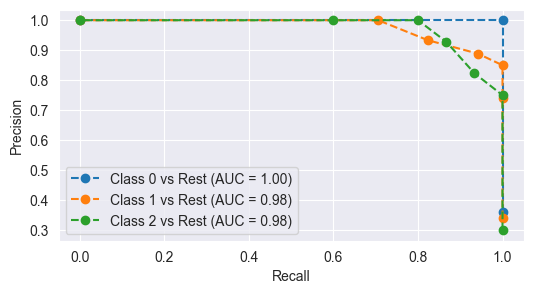

In [47]:
fig, ax = plt.subplots(figsize=(6, 3))

for cls in [0, 1, 2]:
    prc = metrics.precision_recall_curve
    precision, recall, _ = prc(im_test_tgt[:, cls], pred_probs[:, cls])
    prc_auc = metrics.auc(recall, precision)
    label = "Class {} vs Rest (AUC = {:.2f})".format(cls, prc_auc)
    ax.plot(recall, precision, 'o--', label=label)

ax.legend()
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.show()


In [48]:
# negate b/c we want big values first
myorder = np.argsort(-prob_true)
# cumulative sum then to percent (last value is total)
realpct_myorder = iris_1c_test_tgt[myorder].cumsum()
realpct_myorder = realpct_myorder / realpct_myorder[-1]
# convert counts of data into percents
N = iris_1c_test_tgt.size
xs = np.linspace(1/N, 1, N)
print(myorder[:3])

[ 0 28 43]


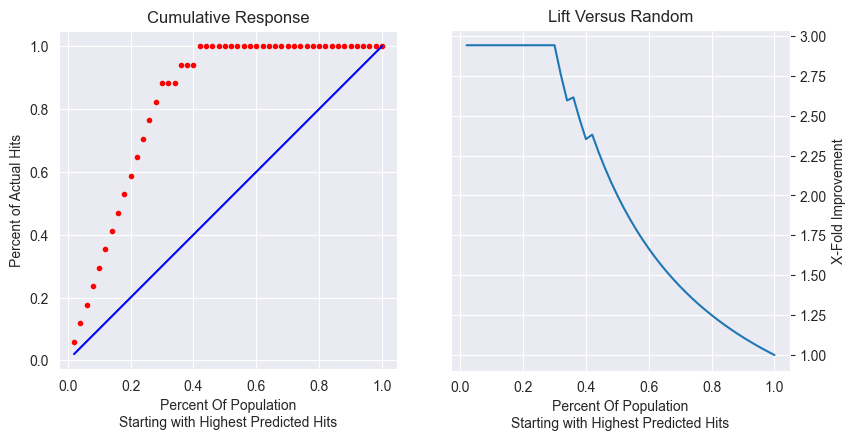

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.tight_layout()

# Cumulative Response
ax1.plot(xs, realpct_myorder, 'r.')
ax1.plot(xs, xs, 'b-')  # Baseline diagonal
ax1.set_aspect('equal')
ax1.set_title("Cumulative Response")
ax1.set_ylabel("Percent of Actual Hits")
ax1.set_xlabel("Percent Of Population\nStarting with Highest Predicted Hits")

# Lift Curve
lift = realpct_myorder / np.where(xs > 0, xs, 1)
ax2.plot(xs, lift)
ax2.set_title("Lift Versus Random")
ax2.set_ylabel("X-Fold Improvement")  # Not cross-fold!
ax2.set_xlabel("Percent Of Population\nStarting with Highest Predicted Hits")
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')

plt.show()


In [50]:
classifiers = {'base' : baseline,
'gnb' : naive_bayes.GaussianNB(),
'3-NN' : neighbors.KNeighborsClassifier(n_neighbors=10),
'10-NN' : neighbors.KNeighborsClassifier(n_neighbors=3)}

In [51]:
# define the one_class iris problem so we don't have random ==1 around
iris_onec_ftrs = iris.data
iris_onec_tgt = iris.target==1

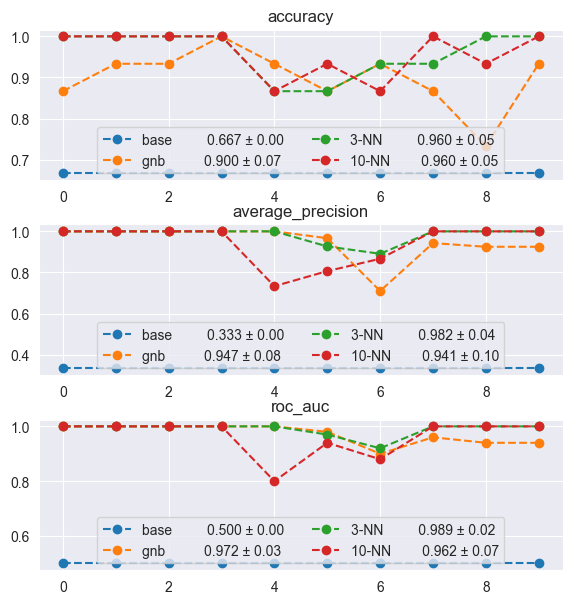

In [52]:
msrs = ['accuracy', 'average_precision', 'roc_auc']

fig, axes = plt.subplots(len(msrs), 1, figsize=(6, 2 * len(msrs)))
fig.tight_layout()

for mod_name, model in classifiers.items():
    cvs = skms.cross_val_score
    cv_results = {
        msr: cvs(model, iris_onec_ftrs, iris_onec_tgt, scoring=msr, cv=10)
        for msr in msrs
    }

    for ax, msr in zip(axes, msrs):
        msr_results = cv_results[msr]
        my_lbl = "{:12s} {:.3f} ± {:.2f}".format(
            mod_name, msr_results.mean(), msr_results.std()
        )
        ax.plot(msr_results, 'o--', label=my_lbl)
        ax.set_title(msr)
        ax.legend(loc='lower center', ncol=2)

plt.show()


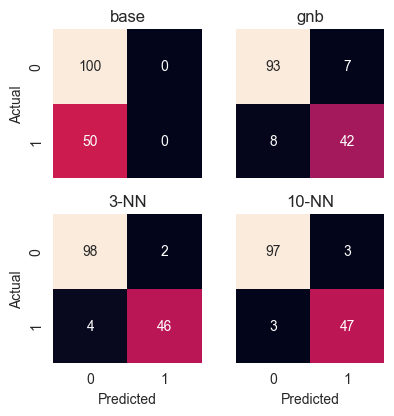

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharex=True, sharey=True)
fig.tight_layout()

for ax, (mod_name, model) in zip(axes.flat, classifiers.items()):
    preds = skms.cross_val_predict(model, iris_onec_ftrs, iris_onec_tgt, cv=10)
    cm = metrics.confusion_matrix(iris.target == 1, preds)
    sns.heatmap(cm, annot=True, ax=ax, cbar=False, square=True, fmt="d")
    ax.set_title(mod_name)

axes[1, 0].set_xlabel('Predicted')
axes[1, 1].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[1, 0].set_ylabel('Actual')
plt.show()


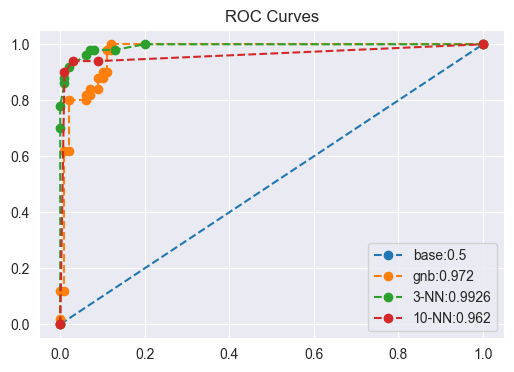

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

cv_prob_true = {}
for mod_name, model in classifiers.items():
    cv_probs = skms.cross_val_predict(
        model,
        iris_onec_ftrs,
        iris_onec_tgt,
        cv=10,
        method='predict_proba'
    )
    cv_prob_true[mod_name] = cv_probs[:, 1]
    fpr, tpr, thresh = metrics.roc_curve(iris_onec_tgt, cv_prob_true[mod_name])
    auc = metrics.auc(fpr, tpr)
    ax.plot(fpr, tpr, 'o--', label="{}:{}".format(mod_name, auc))

ax.set_title('ROC Curves')
ax.legend()
plt.show()


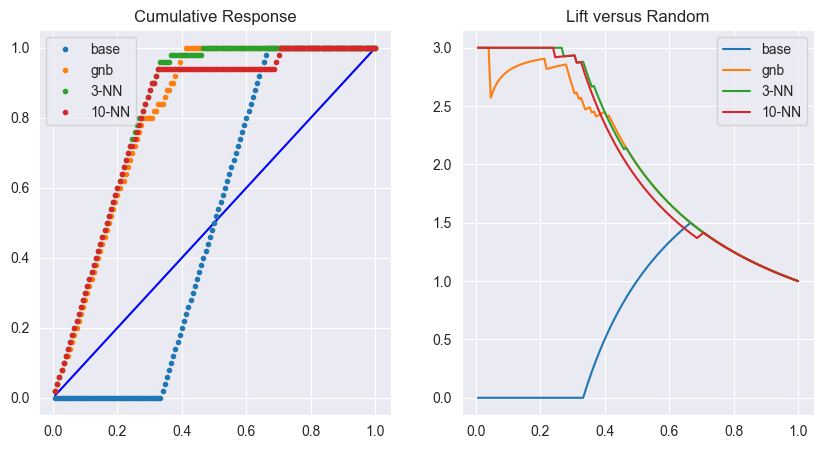

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

N = len(iris_onec_tgt)
xs = np.linspace(1 / N, 1, N)

ax1.plot(xs, xs, 'b-')

for mod_name in classifiers:
    # negate so big values come first
    myorder = np.argsort(-cv_prob_true[mod_name])
    # cumulative sum then to percent (last value is total)
    realpct_myorder = iris_onec_tgt[myorder].cumsum()
    realpct_myorder = realpct_myorder / realpct_myorder[-1]

    ax1.plot(xs, realpct_myorder, '.', label=mod_name)
    ax2.plot(xs, realpct_myorder / np.where(xs > 0, xs, 1), label=mod_name)

ax1.legend()
ax2.legend()
ax1.set_title("Cumulative Response")
ax2.set_title("Lift versus Random")
plt.show()


In [69]:
df = pd.read_csv('data/student-por.csv', sep=';')
print(df.columns)


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [71]:
# Discretize final grade into low/mid/high
bins = [0, 10, 14, 20]
labels = ['low', 'mid', 'high']
df['grade'] = pd.cut(df['G3'], bins=bins, labels=labels, include_lowest=True)
df['grade'] = pd.Categorical(df['grade'], categories=labels, ordered=True)

# Keep only numeric columns and add the grade
df_numeric = df.select_dtypes(include='number').copy()
df_numeric['grade'] = df['grade']

# Save in textbook format
df_numeric.to_csv('data/portugese_student_numeric.csv', index=False)


In [72]:
student_df = pd.read_csv('data/portugese_student_numeric.csv')
student_df['grade'] = pd.Categorical(
    student_df['grade'],
    categories=['low', 'mid', 'high'],
    ordered=True
)

student_ftrs = student_df[student_df.columns[:-1]]
student_tgt = student_df['grade'].cat.codes


In [73]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

knn = KNeighborsClassifier(n_neighbors=3)
scores = cross_val_score(knn, student_ftrs, student_tgt, cv=10, scoring='accuracy')

print("10-fold CV accuracy scores:", scores)
print("Mean accuracy: {:.3f} ± {:.3f}".format(np.mean(scores), np.std(scores)))


10-fold CV accuracy scores: [0.8    0.9231 0.8154 0.7692 0.8923 0.8769 0.8769 0.8154 0.9077 0.7656]
Mean accuracy: 0.844 ± 0.055


In [74]:
student_df = pd.read_csv('data/portugese_student_numeric.csv')
student_df['grade'] = pd.Categorical(student_df['grade'],
categories=['low', 'mid', 'high'],
ordered=True)

In [75]:
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt = student_df['grade'].cat.codes

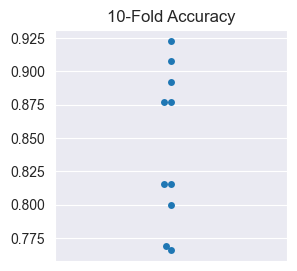

In [76]:
fig,ax = plt.subplots(1, 1, figsize=(3, 3))
model = neighbors.KNeighborsClassifier(3)
cv_auc = skms.cross_val_score(model,
student_ftrs, student_tgt,
scoring='accuracy', cv=10)
ax = sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold Accuracy');

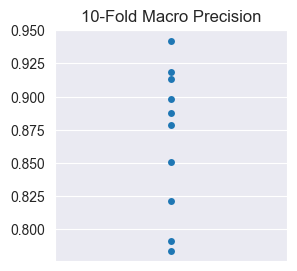

In [77]:
model = neighbors.KNeighborsClassifier(3)
my_scorer = metrics.make_scorer(metrics.precision_score,
average='macro')
cv_auc = skms.cross_val_score(model,
student_ftrs, student_tgt,
scoring=my_scorer, cv=10)
fig,ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold Macro Precision');

In [86]:
from sklearn.linear_model import LogisticRegression

classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Logistic": LogisticRegression(max_iter=2000),  # was too low before
    "Tree": DecisionTreeClassifier()
}


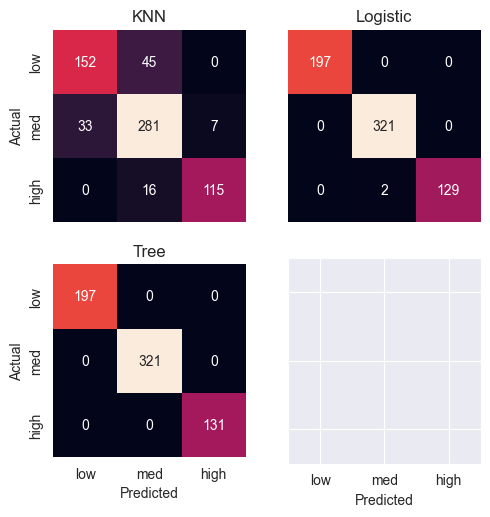

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5), sharex=True, sharey=True)
fig.tight_layout()

for ax, (mod_name, model) in zip(axes.flat, classifiers.items()):
    preds = skms.cross_val_predict(model, student_ftrs, student_tgt, cv=10)
    cm = metrics.confusion_matrix(student_tgt, preds)
    sns.heatmap(
        cm, annot=True, ax=ax, cbar=False, square=True, fmt="d",
        xticklabels=['low', 'med', 'high'],
        yticklabels=['low', 'med', 'high']
    )
    ax.set_title(mod_name)

axes[1, 0].set_xlabel('Predicted')
axes[1, 1].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[1, 0].set_ylabel('Actual')
plt.show()


In [5]:
student_url = (
    'https://archive.ics.uci.edu/' +
    'ml/machine-learning-databases/00320/student.zip'
)

def grab_student_numeric_discrete():
    import urllib.request
    import zipfile
    import pandas as pd

    # Download and extract
    urllib.request.urlretrieve(student_url, 'port_student.zip')
    with zipfile.ZipFile('port_student.zip') as zf:
        zf.extract('student-mat.csv')

    # Load and preprocess
    df = pd.read_csv('student-mat.csv', sep=';')
    df = df.drop(columns=['G1', 'G2']).select_dtypes(include=['number'])
    df['grade'] = pd.cut(
        df['G3'], [0, 11, 14, 20],
        labels=['low', 'mid', 'high'],
        include_lowest=True
    )
    df.drop(columns=['G3'], inplace=True)

    # Save cleaned file
    df.to_csv('portugese_student_numeric.csv', index=False)


In [11]:
import pandas as pd
student_df = pd.read_csv('data/portugese_student_numeric.csv')
student_df['grade'] = pd.Categorical(student_df['grade'],
categories=['low', 'mid', 'high'],
ordered=True)

In [12]:
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt = student_df['grade'].cat.codes

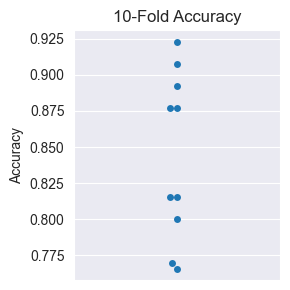

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import neighbors
from sklearn import model_selection as skms

# Define the model
model = neighbors.KNeighborsClassifier(3)

# Perform 10-fold cross-validation using accuracy
cv_auc = skms.cross_val_score(
    model,
    student_ftrs,
    student_tgt,
    scoring='accuracy',
    cv=10
)

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(y=cv_auc, ax=ax, orient='v')  # use y= to suppress FutureWarning
ax.set_title('10-Fold Accuracy')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()


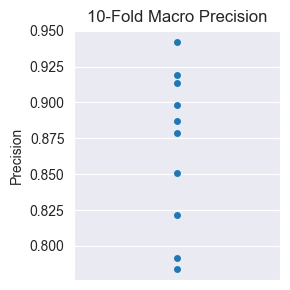

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import neighbors, metrics, model_selection as skms

# Define the KNN model
model = neighbors.KNeighborsClassifier(3)

# Define the macro precision scorer
my_scorer = metrics.make_scorer(
    metrics.precision_score, average='macro', zero_division=0
)

# Run 10-fold cross-validation
cv_auc = skms.cross_val_score(
    model, student_ftrs, student_tgt, scoring=my_scorer, cv=10
)

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(y=cv_auc, ax=ax, orient='v')  # safer with y=
ax.set_title('10-Fold Macro Precision')
ax.set_ylabel('Precision')
plt.tight_layout()
plt.show()
